In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../data/diabetes.csv')

# Basic overview
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("=== Dataset Info ===")
print(df.info())

print("\n=== Basic Statistics ===")
print(df.describe())

print("\n=== Target Column Distribution ===")
print(df['Outcome'].value_counts())
print(f"\nDiabetic (1): {df['Outcome'].sum()} patients")
print(f"Non-Diabetic (0): {(df['Outcome']==0).sum()} patients")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

=== Basic Statistics ===
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      

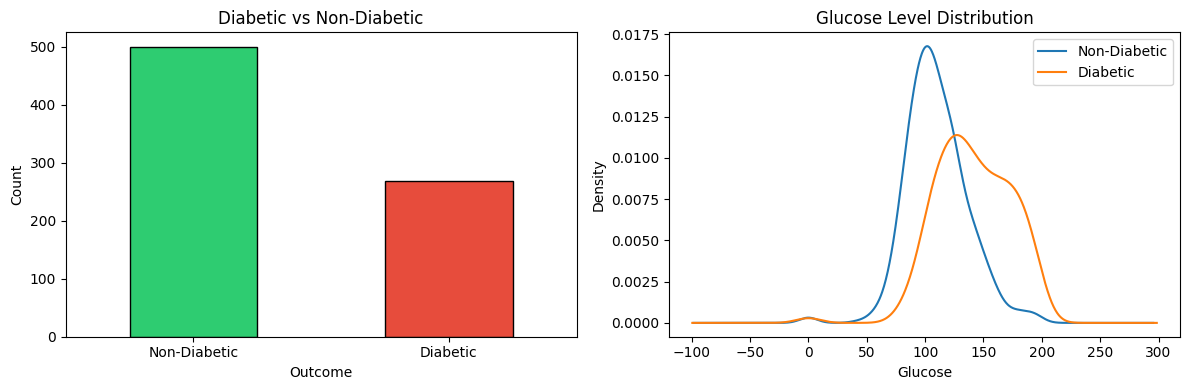

Visualization complete!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Outcome distribution
df['Outcome'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black'
)
axes[0].set_title('Diabetic vs Non-Diabetic')
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'], rotation=0)
axes[0].set_ylabel('Count')

# Glucose distribution by outcome
df.groupby('Outcome')['Glucose'].plot(
    kind='kde', ax=axes[1], legend=True
)
axes[1].set_title('Glucose Level Distribution')
axes[1].set_xlabel('Glucose')
axes[1].legend(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()
print("Visualization complete!")

In [7]:
# These columns CANNOT have 0 as valid value
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("=== Zero Values Count (actually missing data) ===")
for col in zero_check_cols:
    zeros = (df[col] == 0).sum()
    percent = (zeros / len(df)) * 100
    print(f"{col}: {zeros} zeros ({percent:.1f}%)")

=== Zero Values Count (actually missing data) ===
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [9]:
# Replace 0s with column median (safer than mean for medical data)
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df_clean = df.copy()
for col in cols_to_fix:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

print("=== After Fixing Zero Values ===")
for col in cols_to_fix:
    zeros = (df_clean[col] == 0).sum()
    print(f"{col}: {zeros} zeros remaining")

print("\nData cleaned successfully!")

=== After Fixing Zero Values ===
Glucose: 0 zeros remaining
BloodPressure: 0 zeros remaining
SkinThickness: 0 zeros remaining
Insulin: 0 zeros remaining
BMI: 0 zeros remaining

Data cleaned successfully!


In [10]:
X = df_clean.drop('Outcome', axis=1)   # Features (8 columns)
y = df_clean['Outcome']                 # Target (0 or 1)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", list(X.columns))

Features shape: (768, 8)
Target shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [12]:
# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")
print("\nData scaled and split successfully!")
print("Dataset is 100% ready for model training!")

Training set size:  614 samples
Testing set size:   154 samples

Data scaled and split successfully!
Dataset is 100% ready for model training!


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

print("All 4 models imported!")

All 4 models imported!


In [14]:
# Define all models
models = {
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Train all models and store results
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        "model": model,
        "predictions": y_pred,
        "accuracy": acc
    }
    print(f" {name} trained — Accuracy: {acc*100:.2f}%")

 KNN trained — Accuracy: 70.78%
 Naive Bayes trained — Accuracy: 69.48%
 SVM trained — Accuracy: 72.73%
 Decision Tree trained — Accuracy: 66.88%


In [15]:
for name, result in results.items():
    print("=" * 50)
    print(f"  MODEL: {name}")
    print("=" * 50)
    
    print(f"\n Accuracy: {result['accuracy']*100:.2f}%")
    
    print("\n Classification Report:")
    print(classification_report(y_test, result['predictions'],
          target_names=['Non-Diabetic', 'Diabetic']))
    
    print("\n Confusion Matrix:")
    cm = confusion_matrix(y_test, result['predictions'])
    print(cm)
    print()

  MODEL: KNN

 Accuracy: 70.78%

 Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.81      0.78       100
    Diabetic       0.60      0.52      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154


 Confusion Matrix:
[[81 19]
 [26 28]]

  MODEL: Naive Bayes

 Accuracy: 69.48%

 Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.74      0.76       100
    Diabetic       0.56      0.61      0.58        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154


 Confusion Matrix:
[[74 26]
 [21 33]]

  MODEL: SVM

 Accuracy: 72.73%

 Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.76      0.8

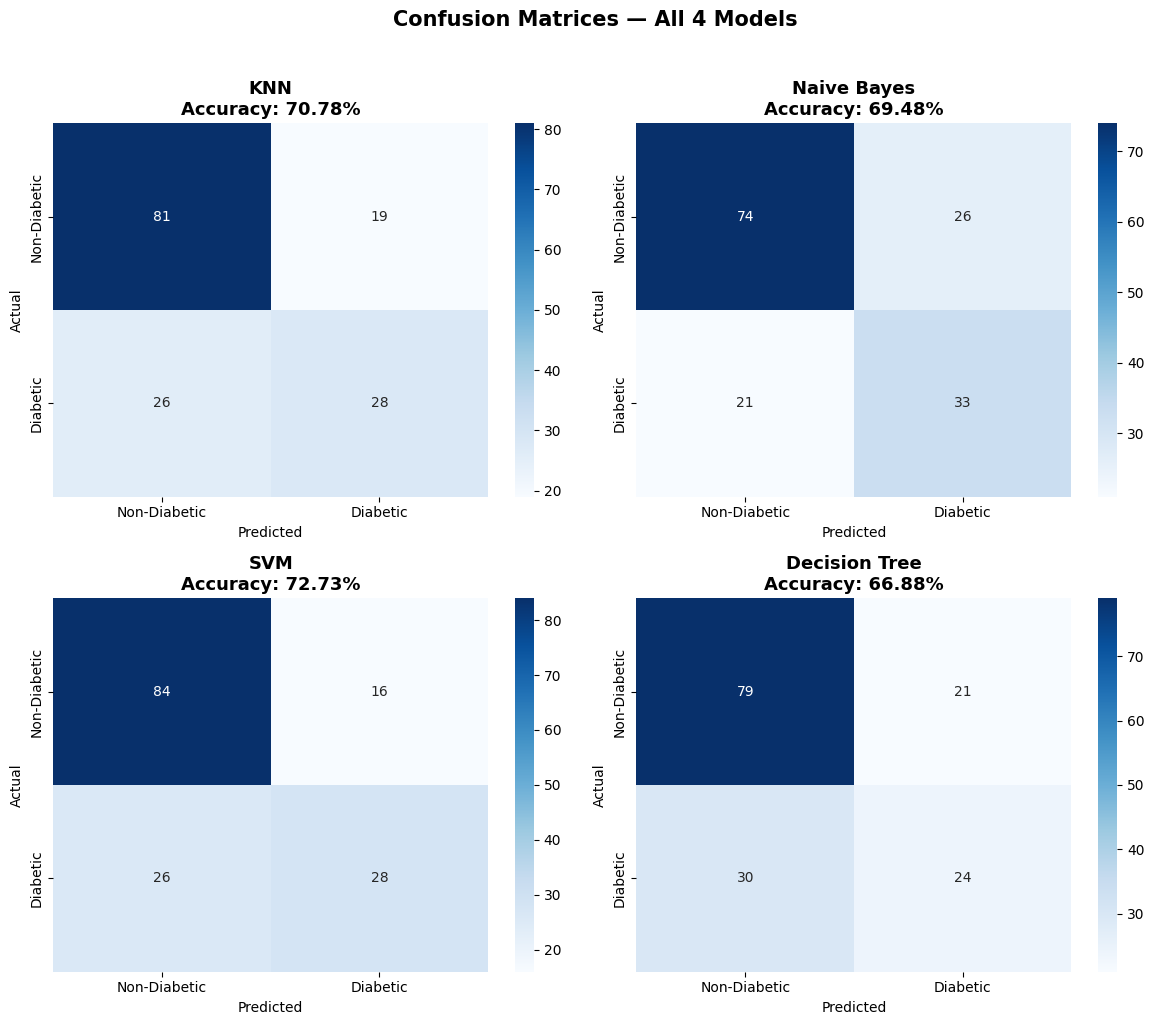

 Confusion matrices saved!


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx],
                cmap='Blues',
                xticklabels=['Non-Diabetic', 'Diabetic'],
                yticklabels=['Non-Diabetic', 'Diabetic'])
    
    axes[idx].set_title(f'{name}\nAccuracy: {result["accuracy"]*100:.2f}%',
                        fontsize=13, fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All 4 Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../confusion_matrices.png', bbox_inches='tight')
plt.show()
print(" Confusion matrices saved!")

In [19]:
print("\n" + "=" * 45)
print(" MODEL ACCURACY COMPARISON")
print("=" * 45)
print(f"{'Model':<20} {'Accuracy':>10} {'Rank':>8}")
print("-" * 45)

# Sort by accuracy
sorted_results = sorted(results.items(),
                        key=lambda x: x[1]['accuracy'],
                        reverse=True)

for rank, (name, result) in enumerate(sorted_results, 1):
    print(f"{name:<20} {result['accuracy']*100:>9.2f}% ")

print("=" * 45)
best_model_name = sorted_results[0][0]
best_accuracy = sorted_results[0][1]['accuracy']
print(f"\n Best Model: {best_model_name} with {best_accuracy*100:.2f}% accuracy")


 MODEL ACCURACY COMPARISON
Model                  Accuracy     Rank
---------------------------------------------
SVM                      72.73% 
KNN                      70.78% 
Naive Bayes              69.48% 
Decision Tree            66.88% 

 Best Model: SVM with 72.73% accuracy


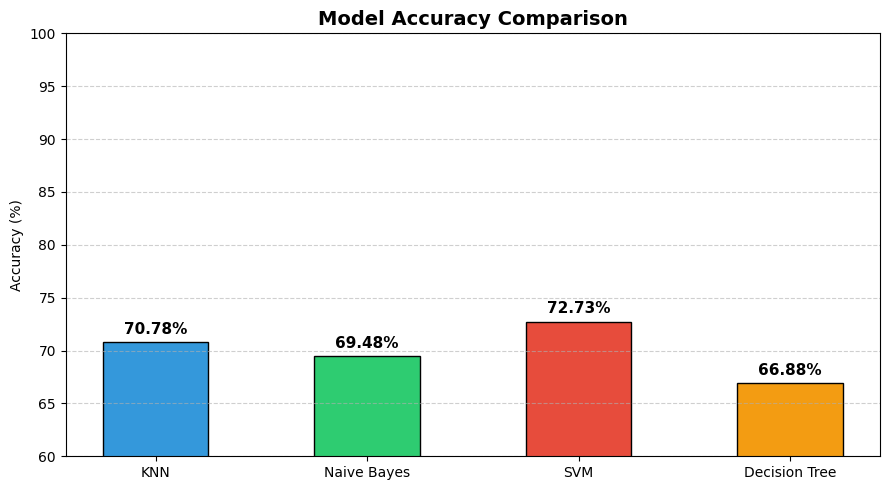

 Accuracy chart saved!


In [20]:
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in model_names]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, accuracies, color=colors,
               edgecolor='black', width=0.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center',
             va='bottom', fontweight='bold', fontsize=11)

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(60, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../accuracy_comparison.png', bbox_inches='tight')
plt.show()
print(" Accuracy chart saved!")

In [23]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Get the best model (SVM) from results
best_model = results['SVM']['model']

# Save the best model
joblib.dump(best_model, '../models/best_model.pkl')
print(" best_model.pkl saved! (SVM — 72.73%)")

# Save the scaler (VERY important — must use same scaler in app)
joblib.dump(scaler, '../models/scaler.pkl')
print(" scaler.pkl saved!")

print("\n Both files saved in models/ folder")

 best_model.pkl saved! (SVM — 72.73%)
 scaler.pkl saved!

 Both files saved in models/ folder


In [24]:
# Confirm files exist
model_path = '../models/best_model.pkl'
scaler_path = '../models/scaler.pkl'

if os.path.exists(model_path):
    size = os.path.getsize(model_path)
    print(f" best_model.pkl — Found! Size: {size} bytes")
else:
    print(" best_model.pkl — NOT found!")

if os.path.exists(scaler_path):
    size = os.path.getsize(scaler_path)
    print(f" scaler.pkl     — Found! Size: {size} bytes")
else:
    print(" scaler.pkl — NOT found!")

 best_model.pkl — Found! Size: 31419 bytes
 scaler.pkl     — Found! Size: 1127 bytes


In [26]:
# Reload model and scaler fresh (simulating what the app will do)
loaded_model = joblib.load('../models/best_model.pkl')
loaded_scaler = joblib.load('../models/scaler.pkl')

# Dummy patient data for testing
# [Pregnancies, Glucose, BP, SkinThickness, Insulin, BMI, DPF, Age]
test_patient = np.array([[2, 138, 62, 35, 0, 33.6, 0.127, 47]])

# Scale it
test_scaled = loaded_scaler.transform(test_patient)

# Predict
prediction = loaded_model.predict(test_scaled)
probability = loaded_model.predict_proba(test_scaled)

print(" Test Patient Data:")
print(f" Pregnancies: 2, Glucose: 138, BP: 62")
print(f" BMI: 33.6, Age: 47\n")

print(f" Prediction: {' Diabetic' if prediction[0] == 1 else ' Non-Diabetic'}")
print(f" Confidence: {max(probability[0])*100:.2f}%")
print("\n Model loads and predicts correctly!")

 Test Patient Data:
 Pregnancies: 2, Glucose: 138, BP: 62
 BMI: 33.6, Age: 47

 Prediction:  Non-Diabetic
 Confidence: 61.34%

 Model loads and predicts correctly!
